# IBM Telco Customer Churn: Exploratory Data Analysis

Welcome! In this analysis, we will walk through a professional, production-grade **Exploratory Data Analysis (EDA)** on the IBM Telco Customer Churn dataset. As your mentor, I will guide you through understanding the dataset, handling real-world data issues, uncovering deep churn insights, and formatting our findings into actionable business strategies.

## Business Objectives & Context
**Customer churn** occurs when customers stop doing business with a company. In the telecom industry, acquiring new customers is often significantly more expensive than retaining existing ones. Consequently, predicting and preventing customer churn is a top strategic priority for business leaders.

Our objectives are:
1. **Understand the Target**: Analyze churn distribution and class imbalance.
2. **Clean & Preprocess**: Identify and clean data anomalies (like missing values disguised as spaces).
3. **Analyze Numerical Behaviors**: Inspect how customer tenure, monthly charges, and total charges relate to churn.
4. **Analyze Categorical Drivers**: Discover which services, contracts, and demographic features correlate with attrition.
5. **Synthesize Insights**: Provide data-driven recommendations for business stakeholders.

--- 
## Step 1: Libraries & Settings Setup
Let's start by importing our scientific computing and visualization packages. We'll set a cohesive, professional aesthetic style using Seaborn and Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set custom styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

print("Libraries loaded and styling configured successfully!")

Libraries loaded and styling configured successfully!


--- 
## Step 2: Data Ingestion
We will load the IBM Telco Customer Churn dataset directly from its official public GitHub repository.

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


--- 
## Step 3: Data Cleaning & Type Conversion
Let's inspect the data types of our columns. Pay close attention: sometimes numerical features are parsed as string objects due to formatting discrepancies.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


> [!IMPORTANT]
> **Mentor Tip**: Look closely at `TotalCharges`. It is listed as an `object` type (string) rather than a float, even though its values represent currency. Why? In real-world datasets, missing values are often filled with spaces (" ") or empty strings instead of standard nulls (`NaN`). Let's identify these empty spaces, convert `TotalCharges` to numeric, and see where they came from.

In [4]:
# Find rows where TotalCharges is just empty spaces
empty_space_rows = df[df['TotalCharges'].str.strip() == '']
print(f"Found {len(empty_space_rows)} rows with empty space in TotalCharges.")

# Display tenure of these customers
empty_space_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Found 11 rows with empty space in TotalCharges.


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


> [!NOTE]
> **Business Understanding Insight**: Notice that all these customers have a `tenure` of `0`! They are brand new customers who joined in the current billing cycle. Since they haven't completed their first month of service, their `TotalCharges` are empty. This is a crucial business discovery—these aren't random data entry errors; they represent zero-tenure users.
>
> Let's convert `TotalCharges` to a numeric column and impute these missing values with `0` or the customer's `MonthlyCharges`.

In [5]:
# Convert to numeric, forcing errors (empty spaces) to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaNs in TotalCharges with 0 (since tenure is 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print("TotalCharges successfully converted to float and missing values imputed.")
print(f"Remaining missing values in dataset: {df.isnull().sum().sum()}")

TotalCharges successfully converted to float and missing values imputed.
Remaining missing values in dataset: 0


--- 
## Step 4: Target Class Analysis & Imbalance Detection
Analyzing class distribution in the target variable is one of the most critical steps in any machine learning task. Let's evaluate the distribution of the target variable `Churn`.

In [6]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn Value Counts:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_percentages)

Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


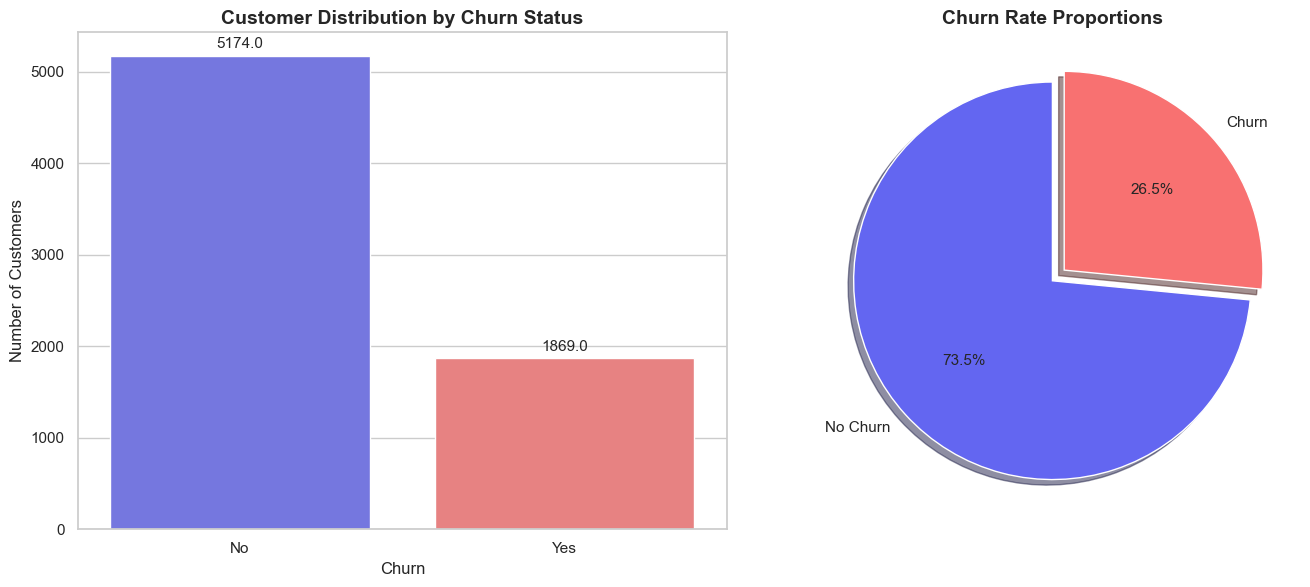

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
sns.countplot(x='Churn', data=df, ax=ax[0], palette=['#6366f1', '#f87171'])
ax[0].set_title('Customer Distribution by Churn Status', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Number of Customers')
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height() + 50), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Pie chart
ax[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', startangle=90, 
        colors=['#6366f1', '#f87171'], explode=(0, 0.08), shadow=True)
ax[1].set_title('Churn Rate Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

> [!WARNING]
> **Mentor Tip: Imbalance Detection**: The churn rate is **26.5%**, while active retention is **73.5%**. This is a classic class imbalance problem. If we build an ML model without addressing this imbalance (e.g., using stratified splits, weighted loss, or sampling techniques), the model might simply predict 'No Churn' for all customers and achieve 73.5% accuracy while completely failing to identify actual churned customers.

--- 
## Step 5: Numerical Features Analysis
The dataset contains three key numeric variables:
1. `tenure`: Number of months the customer has been with the company.
2. `MonthlyCharges`: The monthly amount charged to the customer.
3. `TotalCharges`: The total amount charged to the customer.

Let's visualize their distributions using Kernel Density Estimation (KDE) plots to compare behavior for churned vs. active customers.

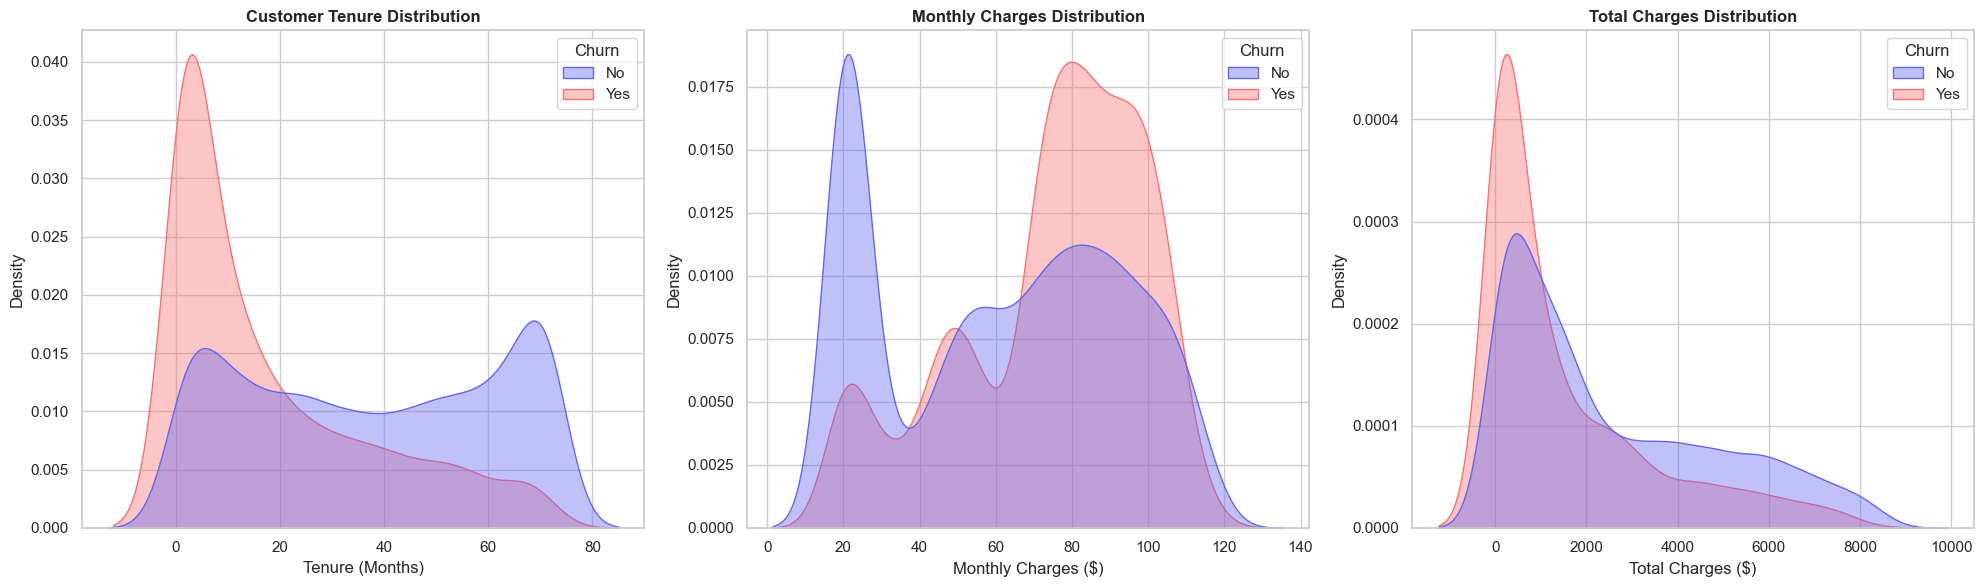

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tenure KDE
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, 
            palette=['#6366f1', '#f87171'], ax=axes[0], alpha=0.4)
axes[0].set_title('Customer Tenure Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')

# Monthly Charges KDE
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, 
            palette=['#6366f1', '#f87171'], ax=axes[1], alpha=0.4)
axes[1].set_title('Monthly Charges Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')

# Total Charges KDE
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, common_norm=False, 
            palette=['#6366f1', '#f87171'], ax=axes[2], alpha=0.4)
axes[2].set_title('Total Charges Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.show()

> [!NOTE]
> **Churn Insights (Numerical Variables)**:
> - **Tenure**: Extremely clear signal. Customers who churn are highly concentrated in their first 1-12 months. If a customer stays past 20 months, their risk of churn drops significantly. Brand new customers need special onboarding attention!
> - **Monthly Charges**: Customers who churn have a much higher concentration around $70–$110. Customers with low monthly charges (below $30) rarely churn. This indicates price sensitivity or dissatisfaction with premium packages.
> - **Total Charges**: Churned customers have low total charges because they leave early in their lifecycle (short tenure).

--- 
## Step 6: Categorical Drivers of Churn
Let's explore the relationship between churn and categorical attributes, particularly service components and contract types.

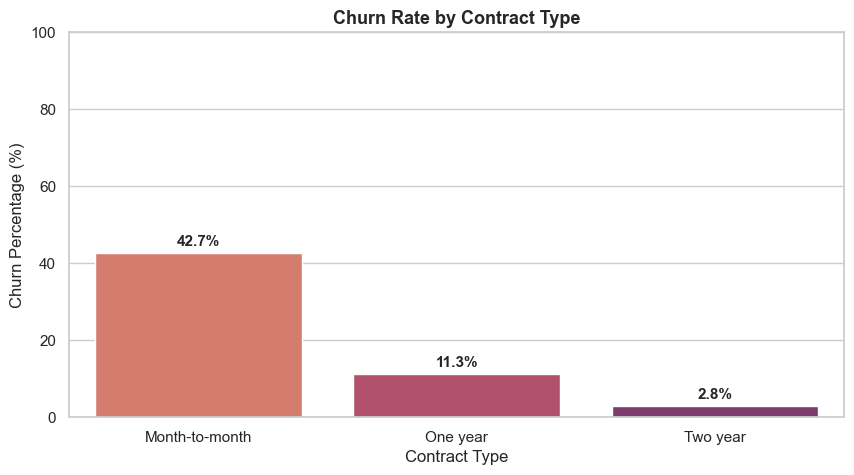

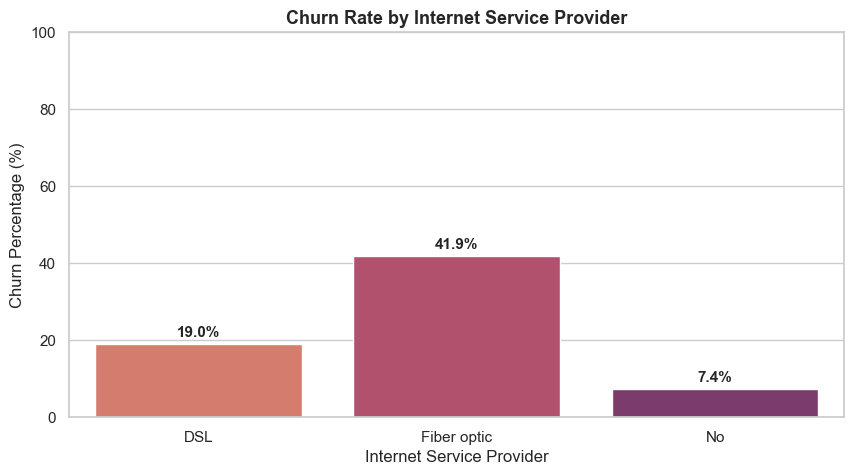

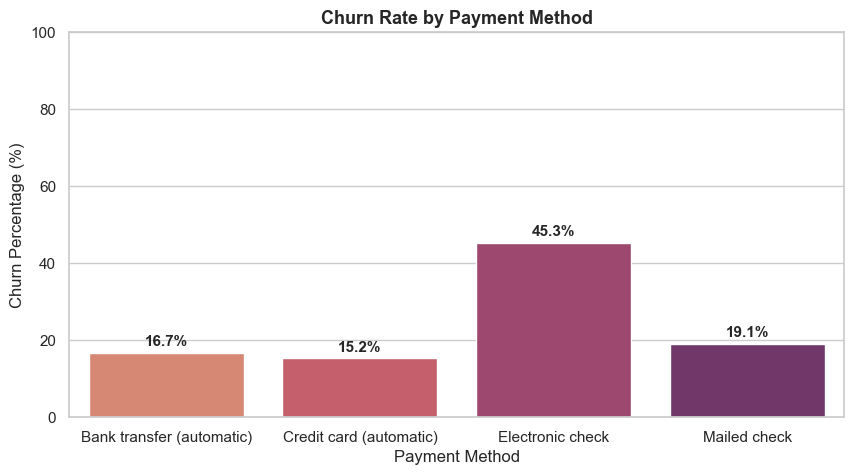

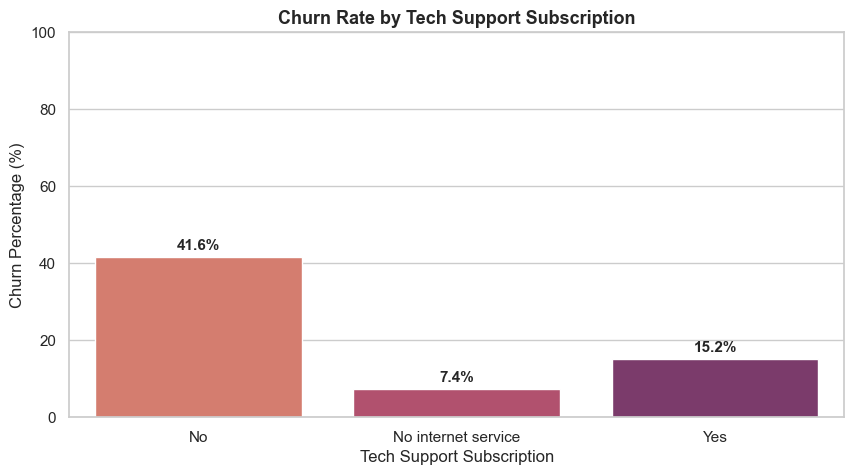

In [9]:
def plot_churn_rate_by_categorical(feature, title):
    # Calculate churn rate per category
    churn_by_cat = df.groupby(feature)['Churn'].value_counts(normalize=True).unstack() * 100
    churn_by_cat = churn_by_cat.reset_index()
    
    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(x=feature, y='Yes', data=churn_by_cat, palette='flare')
    plt.title(f'Churn Rate by {title}', fontsize=13, fontweight='bold')
    plt.ylabel('Churn Percentage (%)')
    plt.xlabel(title)
    for p in plt.gca().patches:
        plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')
    plt.ylim(0, 100)
    plt.show()

plot_churn_rate_by_categorical('Contract', 'Contract Type')
plot_churn_rate_by_categorical('InternetService', 'Internet Service Provider')
plot_churn_rate_by_categorical('PaymentMethod', 'Payment Method')
plot_churn_rate_by_categorical('TechSupport', 'Tech Support Subscription')

> [!NOTE]
> **Churn Insights (Categorical Drivers)**:
> 1. **Contract Type**: Churn for **Month-to-month** contracts is massive (**42.7%**), whereas **One-year** is **11.3%** and **Two-year** is a tiny **2.8%**. Contract conversion is the single most powerful lever to reduce attrition.
> 2. **Internet Service**: Customers with **Fiber Optic** internet churn at a much higher rate (**41.9%**) compared to **DSL** (**19.0%**). This is anomalous—fiber is typically a high-speed service. This points to technical issues, network drops, or pricing complaints specific to Fiber Optic services.
> 3. **Payment Method**: Customers paying via **Electronic Check** churn at **45.3%**, far higher than those on automated payment systems (Credit Card/Bank Transfer ~15-16%). Manual check processing increases payment frictions.
> 4. **Tech Support**: Customers without tech support churn at **41.6%**, whereas those with tech support churn at **15.2%**. Offering reliable tech support provides huge customer retention value.

--- 
## Step 7: Feature Correlation Analysis
To analyze correlations across numerical and categorical features, we will first encode binary categorical columns (like `Gender`, `Churn`) into numeric markers (0/1) and compute the Pearson correlation matrix.

In [10]:
# Copy data for correlation analysis
corr_df = df.copy()

# drop customerID as it is unique identifier
corr_df.drop('customerID', axis=1, inplace=True)

# Encode binary variables
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    corr_df[col] = corr_df[col].map({'Yes': 1, 'No': 0})

# Encode Gender
corr_df['gender'] = corr_df['gender'].map({'Female': 1, 'Male': 0})

# Convert multi-class categorical columns to dummy variables
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                    'Contract', 'PaymentMethod']

corr_df = pd.get_dummies(corr_df, columns=categorical_cols, drop_first=True)

# Calculate correlation of all features with Churn
churn_corr = corr_df.corr()['Churn'].sort_values(ascending=False)
print("Top Positive and Negative Correlations with Churn:")
print(churn_corr)

Top Positive and Negative Correlations with Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                   0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674

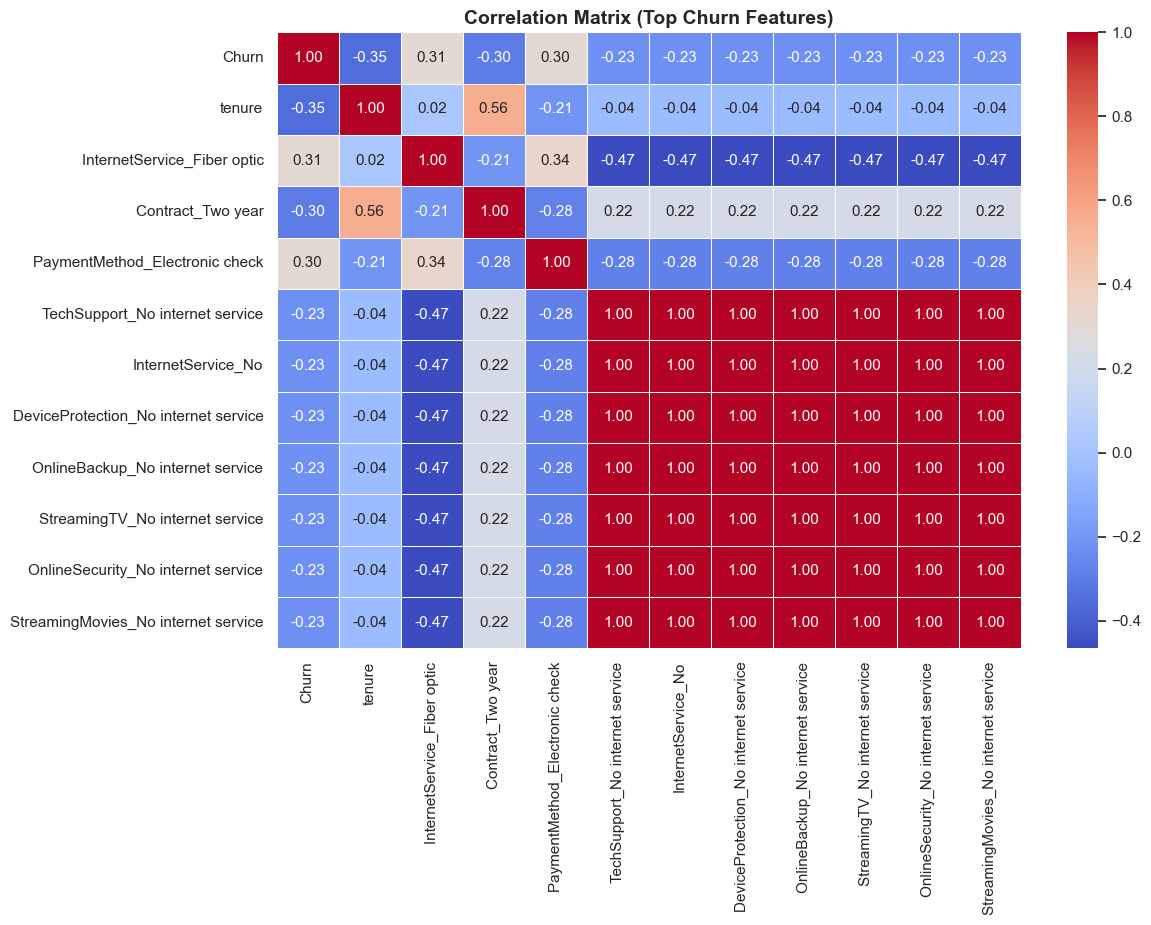

In [11]:
# Plot correlation heatmap for top features
top_corr_features = churn_corr.abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Top Churn Features)', fontsize=14, fontweight='bold')
plt.show()

--- 
## Step 8: Business Summary & Actionable Recommendations

Based on our deep dive into the IBM Telco Churn dataset, we have mapped out clear retention plays for the business teams:

### 1. **The Contract Transition Play**
- **Insight**: Month-to-month contracts exhibit a **42.7%** churn rate, while two-year agreements exhibit a **2.8%** churn rate.
- **Action**: Provide promotional incentives (e.g., $5 monthly discount, premium add-ons for free) to transition month-to-month subscribers into 1-year or 2-year commitments. Focus marketing campaigns particularly on customers around month 10-12 of their contracts.

### 2. **Fiber Optic Quality Assurance Play**
- **Insight**: Fiber Optic customers have an alarming **41.9%** churn rate compared to DSL (19.0%), despite fiber being a superior technological product.
- **Action**: Deploy technical surveys to fiber optic customers in their first 90 days. Investigate fiber connection reliability, speed throttling, and pricing complaints. Address churn caused by customer service delays.

### 3. **Paperless & Auto-Pay Conversion Play**
- **Insight**: Electronic Check users experience a **45.3%** churn rate.
- **Action**: Offer a one-time statement credit (e.g., $10) to migrate electronic check users to bank transfer or credit card auto-pay systems. This removes payment frictions and prevents transactional failures.

### 4. **Support and Retention Bundling Play**
- **Insight**: Customers who do not subscribe to Tech Support experience a **41.6%** churn rate, while those with support drop to **15.2%**.
- **Action**: Bundle online security, backup, and technical support directly into premium plans. Run product tours demonstrating the value of tech support to subscribers without these add-ons.